# Treinando uma rede neural simples com PyTorch usando MNIST

Vamos construir a primeira parte de um sistema de Deep Learning aplicado a uma API.

A ideia é separar claramente duas responsabilidades:

```text
FASE 1 — Treinamento
MNIST → PyTorch → treino → avaliação → modelo salvo

FASE 2 — Uso em aplicação
imagem → API → modelo treinado → predição → JSON
```

Neste notebook, vamos trabalhar apenas a **Fase 1**.

Ao final, teremos um arquivo com os pesos treinados do modelo. Esse arquivo será usado depois por uma API em FastAPI.

## 1. Objetivos da aula

Ao final deste notebook, você deverá entender:

- como carregar um dataset de imagens usando `torchvision`;
- como uma imagem vira um tensor;
- como criar uma rede neural simples com PyTorch;
- como treinar o modelo;
- como avaliar a acurácia;
- como fazer uma predição manual;
- como salvar o modelo treinado em disco.

> Importante: como esta é uma primeira aula com PyTorch, vamos usar uma rede neural simples, totalmente conectada.  
> Em aulas futuras, podemos substituir essa arquitetura por uma CNN, mais adequada para imagens.

## 2. Importação das bibliotecas

Vamos começar importando as bibliotecas principais.

Usaremos:

- `torch`: biblioteca principal do PyTorch;
- `torch.nn`: módulo para criar redes neurais;
- `torchvision`: ferramentas para datasets e transformações de imagens;
- `matplotlib`: visualização das imagens.

In [3]:
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import matplotlib.pyplot as plt

## 3. Verificando o dispositivo de execução

O PyTorch pode executar em CPU ou GPU.

Neste exemplo, vamos detectar automaticamente se existe GPU disponível.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo utilizado:", device)

Dispositivo utilizado: cpu


## 4. Carregando o dataset MNIST

O MNIST é um dataset clássico de dígitos manuscritos.

Cada imagem representa um número de `0` a `9`.

Características principais:

- imagens em escala de cinza;
- tamanho `28 x 28` pixels;
- 10 classes possíveis;
- problema de classificação.

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Quantidade de imagens de treino:", len(train_dataset))
print("Quantidade de imagens de teste:", len(test_dataset))

100.0%
100.0%
100.0%
100.0%

Quantidade de imagens de treino: 60000
Quantidade de imagens de teste: 10000


## 5. Visualizando algumas imagens

Antes de treinar qualquer modelo, é importante olhar os dados.

Cada item do dataset possui:

```text
imagem, rótulo
```

A imagem já vem como tensor porque usamos `transforms.ToTensor()`.

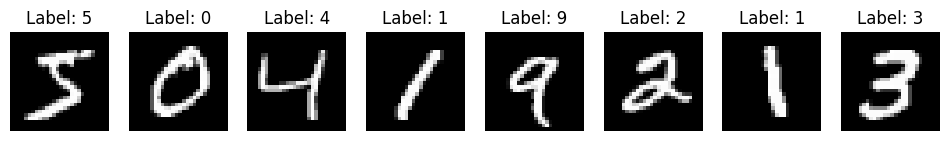

In [6]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))

for i, ax in enumerate(axes):
    image, label = train_dataset[i]

    # image possui formato [1, 28, 28]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.show()

## 6. Entendendo o formato de uma imagem

Vamos pegar uma única imagem e analisar seu formato.

No PyTorch, imagens normalmente usam o formato:

```text
[canais, altura, largura]
```

Como o MNIST está em escala de cinza, há apenas 1 canal.

In [7]:
image, label = train_dataset[0]

print("Formato da imagem:", image.shape)
print("Rótulo:", label)
print("Menor valor no tensor:", image.min().item())
print("Maior valor no tensor:", image.max().item())

Formato da imagem: torch.Size([1, 28, 28])
Rótulo: 5
Menor valor no tensor: -0.4242129623889923
Maior valor no tensor: 2.821486711502075


## 7. Criando os DataLoaders

Durante o treino, não processamos todas as imagens de uma vez.

O `DataLoader` organiza o dataset em pequenos grupos chamados **batches**.

Isso permite treinar o modelo de forma mais eficiente.

In [8]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

images_batch, labels_batch = next(iter(train_loader))

print("Formato do batch de imagens:", images_batch.shape)
print("Formato do batch de rótulos:", labels_batch.shape)

Formato do batch de imagens: torch.Size([64, 1, 28, 28])
Formato do batch de rótulos: torch.Size([64])


O formato do batch de imagens deve ser parecido com:

```text
[64, 1, 28, 28]
```

Isso significa:

```text
[quantidade de imagens, canais, altura, largura]
```

## 8. Criando uma rede neural simples

Vamos criar uma rede neural simples para classificar os dígitos.

A imagem possui `28 x 28` pixels.

Antes de passar pela rede, vamos "achatar" a imagem:

```text
28 x 28 = 784 valores
```

A rede será:

```text
imagem 28x28
   ↓
Flatten
   ↓
Linear(784 → 128)
   ↓
ReLU
   ↓
Linear(128 → 10)
   ↓
saída com 10 valores
```

A saída possui 10 valores porque temos 10 classes possíveis: `0` a `9`.

In [9]:
class RedeNeuralSimples(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.rede = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.rede(x)
        return logits


model = RedeNeuralSimples().to(device)
print(model)

RedeNeuralSimples(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (rede): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 9. Fazendo uma passagem pela rede antes do treino

Antes de treinar, vamos passar um batch pela rede.

Neste momento, o modelo ainda não aprendeu.  
Portanto, suas respostas ainda são praticamente aleatórias.

In [10]:
images_batch, labels_batch = next(iter(train_loader))

images_batch = images_batch.to(device)
labels_batch = labels_batch.to(device)

logits = model(images_batch)

print("Formato da saída do modelo:", logits.shape)
print("Saída da primeira imagem:")
print(logits[0])

Formato da saída do modelo: torch.Size([64, 10])
Saída da primeira imagem:
tensor([ 0.3775,  0.5595, -0.3363, -0.0832,  0.1800,  0.2717, -0.3817,  0.7848,
        -0.1562,  0.0879], grad_fn=<SelectBackward0>)


A saída possui formato:

```text
[64, 10]
```

Isso significa:

- 64 imagens no batch;
- 10 valores de saída para cada imagem.

Esses valores são chamados de **logits**.

Ainda não são probabilidades.  
Para transformar em probabilidades, podemos usar `softmax`.

In [11]:
probabilidades = torch.softmax(logits, dim=1)

print("Probabilidades da primeira imagem:")
print(probabilidades[0])

print("Soma das probabilidades:", probabilidades[0].sum().item())

Probabilidades da primeira imagem:
tensor([0.1198, 0.1437, 0.0587, 0.0756, 0.0983, 0.1078, 0.0561, 0.1801, 0.0703,
        0.0897], grad_fn=<SelectBackward0>)
Soma das probabilidades: 1.0


## 10. Definindo função de perda e otimizador

Para treinar a rede, precisamos de dois componentes principais:

### Função de perda

Mede o quanto o modelo está errando.

Para classificação multiclasse, usamos:

```python
nn.CrossEntropyLoss()
```

### Otimizador

Atualiza os pesos da rede para reduzir o erro.

Aqui usaremos:

```python
torch.optim.Adam()
```

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 11. Criando uma função de treino

Agora vamos criar uma função para treinar o modelo por uma época.

Uma época significa que o modelo passou uma vez por todo o conjunto de treino.

In [13]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # 1. Zera os gradientes acumulados
        optimizer.zero_grad()

        # 2. Forward: calcula a saída do modelo
        logits = model(images)

        # 3. Calcula o erro
        loss = criterion(logits, labels)

        # 4. Backward: calcula os gradientes
        loss.backward()

        # 5. Atualiza os pesos
        optimizer.step()

        # Métricas simples
        total_loss += loss.item() # Acumula a perda do batch
        preds = torch.argmax(logits, dim=1) # Obtém as classes previstas
        correct += (preds == labels).sum().item() # Conta acertos
        total += labels.size(0) # Conta o total de amostras processadas

    avg_loss = total_loss / len(dataloader) # Calcula a perda média do epoch
    accuracy = correct / total # Calcula a acurácia do epoch

    return avg_loss, accuracy

## 12. Criando uma função de avaliação

Na avaliação, não atualizamos os pesos.

Por isso usamos:

```python
model.eval()
torch.no_grad()
```

Isso deixa a execução mais eficiente e evita cálculos desnecessários de gradiente.

In [14]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

## 13. Treinando o modelo

Vamos treinar por poucas épocas para manter a aula rápida.

Mesmo com uma rede simples, o resultado já deve ser razoável para o MNIST.

In [15]:
epochs = 3

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch}/{epochs} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc:.4f} | "
        f"test_loss: {test_loss:.4f} | "
        f"test_acc: {test_acc:.4f}"
    )

Epoch 1/3 | train_loss: 0.2561 | train_acc: 0.9254 | test_loss: 0.1371 | test_acc: 0.9593
Epoch 2/3 | train_loss: 0.1113 | train_acc: 0.9668 | test_loss: 0.1031 | test_acc: 0.9693
Epoch 3/3 | train_loss: 0.0760 | train_acc: 0.9771 | test_loss: 0.0888 | test_acc: 0.9713


## 14. Fazendo uma predição manual

Agora vamos escolher uma imagem do conjunto de teste e pedir para o modelo prever o dígito.

Essa etapa é muito importante didaticamente.

Aqui o aluno percebe que o modelo treinado já consegue receber uma imagem e devolver uma classe.

Rótulo real: 7
Predição do modelo: 7
Probabilidade da classe prevista: 0.9989232420921326


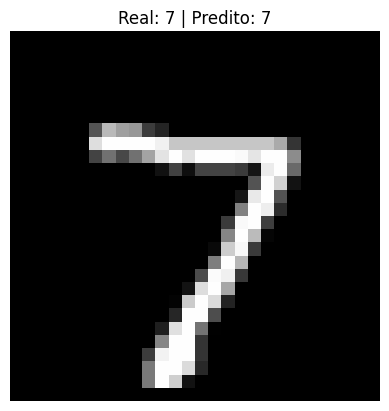

In [16]:
model.eval()

index = 0
image, true_label = test_dataset[index]

with torch.no_grad():
    x = image.unsqueeze(0).to(device)  # adiciona dimensão do batch: [1, 1, 28, 28]
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    predicted_label = torch.argmax(probs, dim=1).item()

print("Rótulo real:", true_label)
print("Predição do modelo:", predicted_label)
print("Probabilidade da classe prevista:", probs[0, predicted_label].item())

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Real: {true_label} | Predito: {predicted_label}")
plt.axis("off")
plt.show()

## 15. Visualizando as probabilidades

Além da classe prevista, podemos observar a probabilidade atribuída a cada dígito.

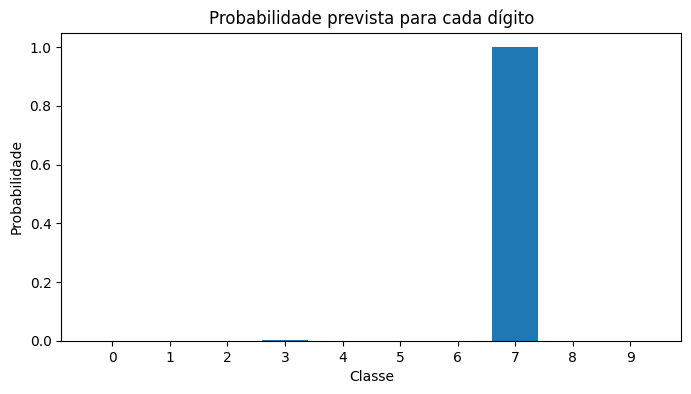

In [17]:
probs_cpu = probs.squeeze().cpu()

plt.figure(figsize=(8, 4))
plt.bar(range(10), probs_cpu)
plt.xticks(range(10))
plt.xlabel("Classe")
plt.ylabel("Probabilidade")
plt.title("Probabilidade prevista para cada dígito")
plt.show()

## 16. Testando várias imagens

Vamos visualizar algumas imagens do conjunto de teste junto com a predição do modelo.

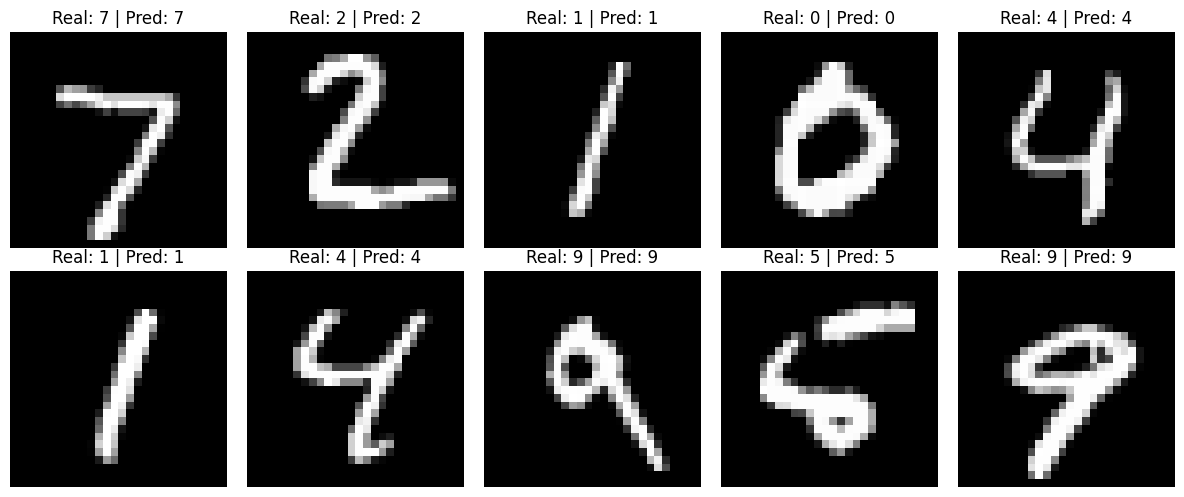

In [18]:
model.eval()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, true_label = test_dataset[i]

    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Real: {true_label} | Pred: {pred}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 17. Salvando o modelo treinado

Agora vamos salvar os pesos aprendidos pela rede.

Essa é a ponte para a próxima parte da aula.

O notebook treina.  
A API carrega o modelo salvo e usa esse conhecimento para responder requisições.

In [19]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / "mnist_mlp.pt"

torch.save(model.state_dict(), model_path)

print("Modelo salvo em:", model_path)

Modelo salvo em: artifacts/mnist_mlp.pt


## 18. Salvando metadados do modelo

Além dos pesos, é útil salvar algumas informações sobre o modelo.

Por exemplo:

- nome da arquitetura;
- classes possíveis;
- média e desvio padrão usados na normalização;
- tamanho esperado da imagem.

Esses metadados ajudam a API a repetir o mesmo pré-processamento usado no treino.

In [20]:
import json

metadata = {
    "model_name": "RedeNeuralSimples",
    "input_shape": [1, 28, 28],
    "classes": list(range(10)),
    "normalization": {
        "mean": 0.1307, 
        "std": 0.3081
    }
}

metadata_path = artifacts_dir / "metadata.json"

metadata_path.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8"
)

print("Metadados salvos em:", metadata_path)

Metadados salvos em: artifacts/metadata.json


## 19. Carregando o modelo salvo para conferir

Antes de encerrar, vamos simular o que a API fará depois:

1. criar a mesma arquitetura;
2. carregar os pesos salvos;
3. colocar o modelo em modo de avaliação;
4. fazer uma predição.

Rótulo real: 2
Predição do modelo carregado: 2


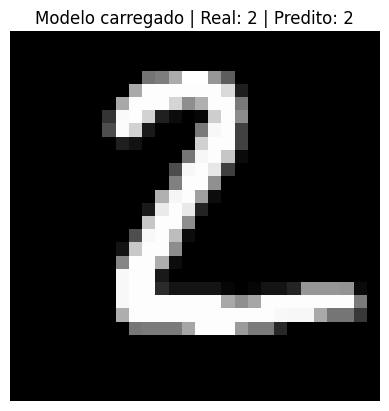

In [21]:
loaded_model = RedeNeuralSimples().to(device)
loaded_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_model.eval()

image, true_label = test_dataset[1]

with torch.no_grad():
    x = image.unsqueeze(0).to(device)
    logits = loaded_model(x)
    pred = torch.argmax(logits, dim=1).item()

print("Rótulo real:", true_label)
print("Predição do modelo carregado:", pred)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Modelo carregado | Real: {true_label} | Predito: {pred}")
plt.axis("off")
plt.show()

## 20. Fechamento da primeira parte

Nesta primeira parte, fizemos o ciclo completo de treinamento:

```text
dados → tensor → modelo → treino → avaliação → predição → modelo salvo
```

Na próxima parte, vamos usar o arquivo salvo:

```text
artifacts/mnist_mlp.pt
```

Esse arquivo será carregado por uma API em FastAPI.

A API não vai treinar o modelo.  
Ela apenas vai usar o modelo treinado para responder novas imagens.

## Desafio

Altere alguns parâmetros e observe o impacto:

1. Mude o número de épocas.
2. Mude a quantidade de neurônios da camada oculta.
3. Teste outra imagem do conjunto de teste.
4. Compare a acurácia antes e depois.
5. Explique por que a API precisa repetir o mesmo pré-processamento usado no treino.